# Multiscale footprint with scprinter

In [1]:
%load_ext autoreload
%autoreload 2
import time
import pandas as pd
import numpy as np
import os
os.environ["SCPRINTER_DATA"] = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
import scprinter as scp

/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. Th

We named is as scprinter, with scp for abbreviation

Following scanpy convention, we use scp.pp = preprocessing scp.tl = tools (computation stuff), scp.pl=plotting (visualizaiton related)

## Section I: import fragments, get insertion and visualize insertion

Prepare the input data
- Fragments file
- barcode grouping 
    - optionally, cell type for each group
- regions

In [2]:
# Specify directories we will use. Make sure you provide the full absolute path and not the relative path
main_dir = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo'
work_dir = f'{main_dir}/seq2print'
if not os.path.exists(work_dir):
    os.system("mkdir -p " + work_dir)
frag_dir = f'{main_dir}/fragments'
if not os.path.exists(frag_dir):
    os.system("mkdir -p " + frag_dir)
work_dir

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print'

In [3]:
# Load the fragments file
import snapatac2 as snap
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo'
samples = ["GW6", "GW12", "GW7", "GW9", "GW10", "GW16", "GW17", "GW20"]
fragment_files = [
    '/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz'
 ]
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/atac-meta.csv", index_col=0)
barcodes_list = []
for sample in samples:
    sample_barcodes = anno[anno['sample2'] == sample]['barcode2'].tolist()
    barcodes_list.append(sample_barcodes)
# Specify the reference genome. This must match that of your ATAC fragments file
genome = scp.genome.hg38

In [4]:
# Initialize the scPrinter object
# When you finish using the object, run printer.close() otherwise you won't be able to load it properly next time.
import time
start = time.time()
printer_path = os.path.join(work_dir, 'HSC_snATAC_oligo_scprinter.h5ad')

if os.path.exists(printer_path):
    printer = scp.load_printer(f'{work_dir}/HSC_snATAC_oligo_scprinter.h5ad', genome)
else:
    # Load data from the fragments file. Needs at least theses four columns: chromosome, start, end, cell barcode
    printer = scp.pp.import_fragments(
                            path_to_frags=fragment_files, 
                            barcodes=barcodes_list,
                            sample_names=samples,
                            savename=printer_path,
                            genome=genome,
                            min_num_fragments=1000, min_tsse=7,
                            sorted_by_barcode=False, 
                            low_memory=False,
                            )

printer
# printer = scp.load_printer(f'{work_dir}/HSC_snATAC_gw12_scprinter.h5ad', genome)
# printer.close()

head project
AnnData object with n_obs x n_vars = 9282 x 0 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/HSC_snATAC_oligo_scprinter.h5ad'
    obs: 'sample', 'n_fragment', 'frac_dup', 'frac_mito', 'frag_path', 'frag_sample_name', 'tsse'
    uns: 'genome', 'group_bigwig', 'binding score', 'gff_db', 'reference_sequences', 'bias_bw', 'bias_path', 'insertion', 'peak_calling', 'footprints', 'unique_string'
    obsm: 'insertion_chr21', 'insertion_chr22', 'insertion_chr3', 'insertion_chr17', 'insertion_chr13', 'insertion_chr2', 'insertion_chrX', 'insertion_chr1', 'insertion_chr14', 'insertion_chr4', 'insertion_chr8', 'insertion_chr18', 'insertion_chr19', 'insertion_chr20', 'insertion_chrY', 'insertion_chr6', 'insertion_chr16', 'insertion_chr15', 'insertion_chr12', 'insertion_chr5', 'insertion_chr11', 'insertion_chr7', 'insertion_chr9', 'insertion_chr10'


In [ ]:
printer

In [6]:
barcode_groups = pd.read_csv(f'{work_dir}/barcode_groups.csv', sep='\t')
barcodes = np.unique(barcode_groups.iloc[:, 0])
barcode_groups

,barcode,group
0,GW16_AAACAGCCACCTCAGG-1,COP
1,GW16_AAACAGCCAGGATGGC-1,COP
2,GW16_AAACATGCAATAACCT-1,OPC
3,GW16_AAACATGCACTAAGTT-1,MFOL
4,GW16_AAACCGAAGAACAAGT-1,dIPC
...,...,...
9277,GW20_TTTGTGGCAAGTCGCT-1,dIPC
9278,GW20_TTTGTGGCACGTAATT-1,OPC
9279,GW20_TTTGTGTTCCGCATGA-1,dIPC
9280,GW20_TTTGTTGGTCACAAAT-1,OPC


In [7]:
regions_dict = {
    # 'chr11:47378230-47379030': 'SPI1', # Highly expressed in monocytes and B cells

    # 'chr21:33115188-33118388': 'OLIG1', # OPC marker 3k bp-m 3200bp
    'chr21:33115188-33115988': 'OLIG1', # OPC marker 3k bp-0 800bp
    'chr21:33115988-33116788': 'OLIG1', # OPC marker 3k bp-1 800bp
    'chr21:33116788-33117588': 'OLIG1', # OPC marker 3k bp-2 800bp
    'chr21:33117588-33118388': 'OLIG1', # OPC marker 3k bp-3 800bp

}


# Save example regions to a bed file
import re
regions_df = []
for region in regions_dict:
    regions_df.append(re.split("[:-]", region))
regions_df = pd.DataFrame(regions_df)
regions_df.to_csv(f'{work_dir}/regions_olig1.bed',
                  sep='\t', header=False, index=False)

In [8]:
regions = pd.read_csv(f'{work_dir}/regions_olig1.bed', sep='\t', header=None)
# regions.columns = ['Chromosome', 'Start', 'End']
regions

,0,1,2
0,chr21,33115188,33115988
1,chr21,33115988,33116788
2,chr21,33116788,33117588
3,chr21,33117588,33118388


In [58]:
grouping, uniq_groups = scp.utils.df2cell_grouping(printer, barcode_groups)
order = ['NPC', 'dIPC', 'OPC', 'COP', 'MFOL', 'MOL']
# searchsorted for bin index
indices = np.searchsorted(uniq_groups, order)
uniq_groups = uniq_groups[indices]
uniq_groups

array(['NPC', 'dIPC', 'OPC', 'COP', 'MFOL', 'MOL'], dtype=object)

First we can use the pl functions to get an idea of the dataset (plotting the Tn5 insertions)

Loading insertion profiles


<Axes: title={'center': 'Tn5 Insertion on chr21:33116788-33117588'}>

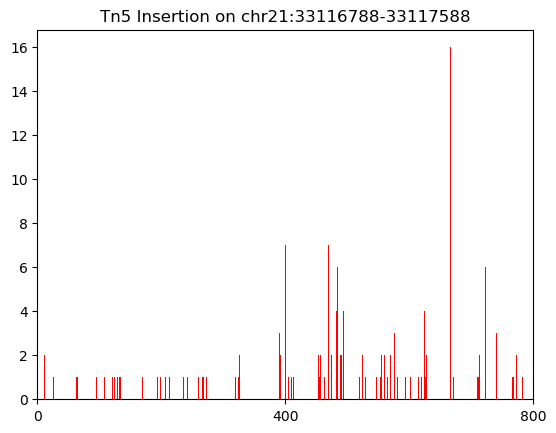

In [10]:
scp.pl.plot_region_atac(printer, # pass the printer project 
                        grouping[2], # plot the first group
                        regions.iloc[2], # plot the 10th region
                        color='red')

It can also plot more than one group in one plot

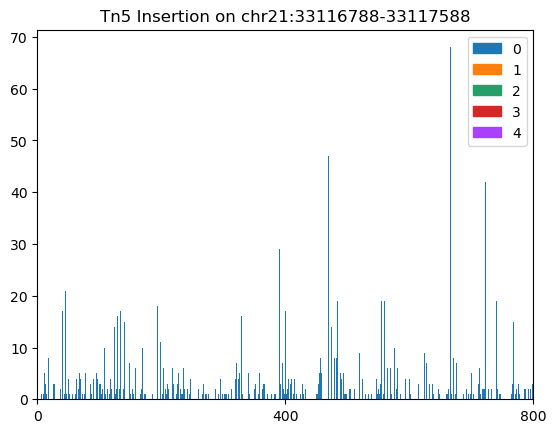

In [11]:
scp.pl.plot_group_atac(printer, 
                       grouping[4:5], 
                       np.arange(5),
                       regions.iloc[2])

You can also parse multiple axs into the function to plot them on different axes to make comparisons

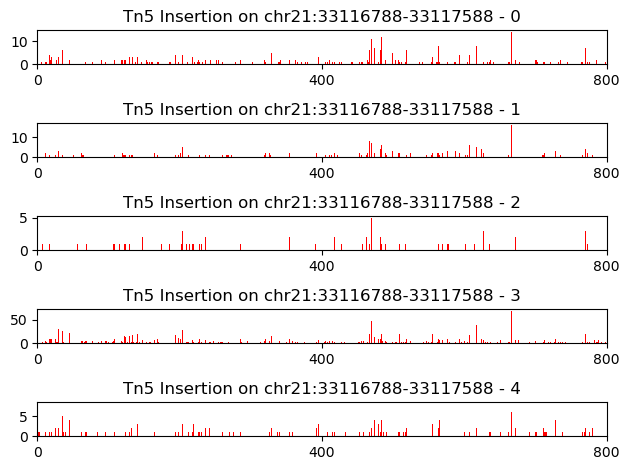

In [12]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(5, 1)
scp.pl.plot_group_atac(printer, 
                       grouping[1:6], 
                       np.arange(5),
                       regions.iloc[2],
                       ax=list(axs), 
                       color="red")

You can also smooth the insertion profile with a window size (5 in this case)

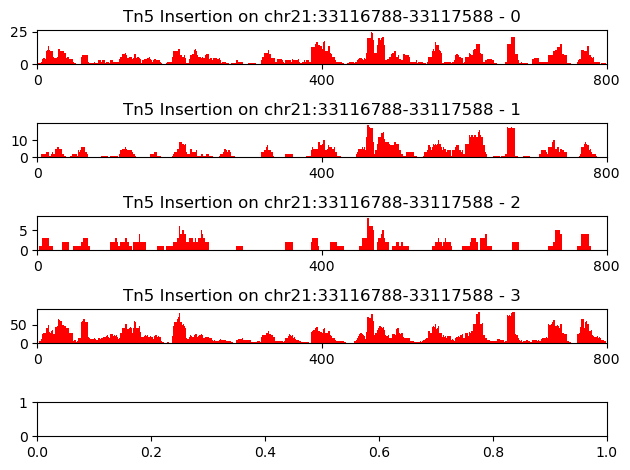

In [15]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(5, 1)
scp.pl.plot_group_atac(printer, 
                       grouping[1:5], 
                       np.arange(5),
                       regions.iloc[2],
                       ax=list(axs), 
                       color="red",
                       smooth=5)

## Section II: Get TFBS score and visualization

Before running get_binding_score, you'll need to load dispersion model and load binidng score model. Note that the load_bindingscore_model takes two arguments. First, a keyword for the model, and second the address of the model. This is preserved for future models that are Nucleosome specific or ... specific family of TFs. 

In [16]:
# Everytime a printer got reload from the disk, you need to reload the binding score model
printer.load_disp_model()
printer.load_bindingscore_model("TF",
                             scp.datasets.pretrained_TFBS_model)
printer.load_bindingscore_model("Nuc",
                             scp.datasets.pretrained_NucBS_model)
import builtins
builtins.long = int
start = time.time()
scp.tl.get_binding_score(
    printer,
    grouping,
    uniq_groups,
    regions,
    model_key='TF',
    n_jobs=10,
    contextRadius=100,
    save_key="trial",
    backed=True,
    overwrite=True)
print ("takes", time.time()-start)

Creating trial in printer.bindingscoreadata
obs=groups, var=regions
Start to get biases
Finish getting biases


submitting jobs:   0%|          | 0/2 [00:00<?, ?it/s]

collecting Binding prediction:   0%|          | 0/4 [00:00<?, ?it/s]

finishes
takes 49.28607630729675


In [18]:
print (printer)
adata = printer.bindingscoreadata['trial']
print (adata)
print (adata.obs)
print (adata.var)
a = adata.obsm['chr21:33115188-33115988']
print (a.shape)

head project
AnnData object with n_obs x n_vars = 9282 x 0 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/HSC_snATAC_oligo_scprinter.h5ad'
    obs: 'sample', 'n_fragment', 'frac_dup', 'frac_mito', 'frag_path', 'frag_sample_name', 'tsse'
    uns: 'genome', 'group_bigwig', 'binding score', 'gff_db', 'reference_sequences', 'bias_bw', 'bias_path', 'insertion', 'peak_calling', 'footprints', 'unique_string'
    obsm: 'insertion_chr21', 'insertion_chr22', 'insertion_chr3', 'insertion_chr17', 'insertion_chr13', 'insertion_chr2', 'insertion_chrX', 'insertion_chr1', 'insertion_chr14', 'insertion_chr4', 'insertion_chr8', 'insertion_chr18', 'insertion_chr19', 'insertion_chr20', 'insertion_chrY', 'insertion_chr6', 'insertion_chr16', 'insertion_chr15', 'insertion_chr12', 'insertion_chr5', 'insertion_chr11', 'insertion_chr7', 'insertion_chr9', 'insertion_chr10'
detected 1 bindingscoreadata
name trial
AnnData object with n_obs x n_vars = 6 x 4 backe

Now let's visualize it!

<Axes: title={'center': 'Binding Score on chr21:33117588-33118388'}>

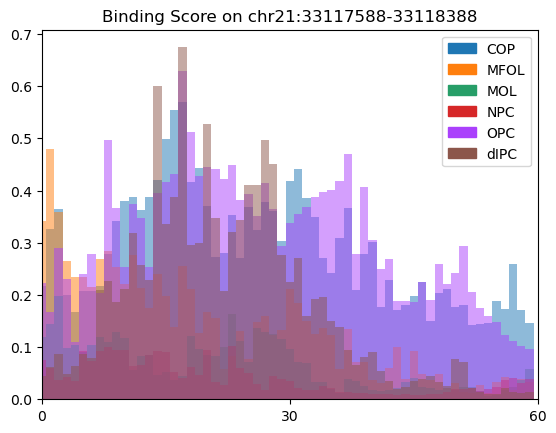

In [25]:
scp.pl.plot_binding_score(printer,
                       save_key='trial',
                       group_names=uniq_groups[0:6],
                       region=regions.iloc[3],
                       ax=None,
                       alpha=0.5)

sort the cells

In [26]:
order =  ['NPC', 'dIPC', 'OPC', 'COP', 'MFOL', 'MOL']

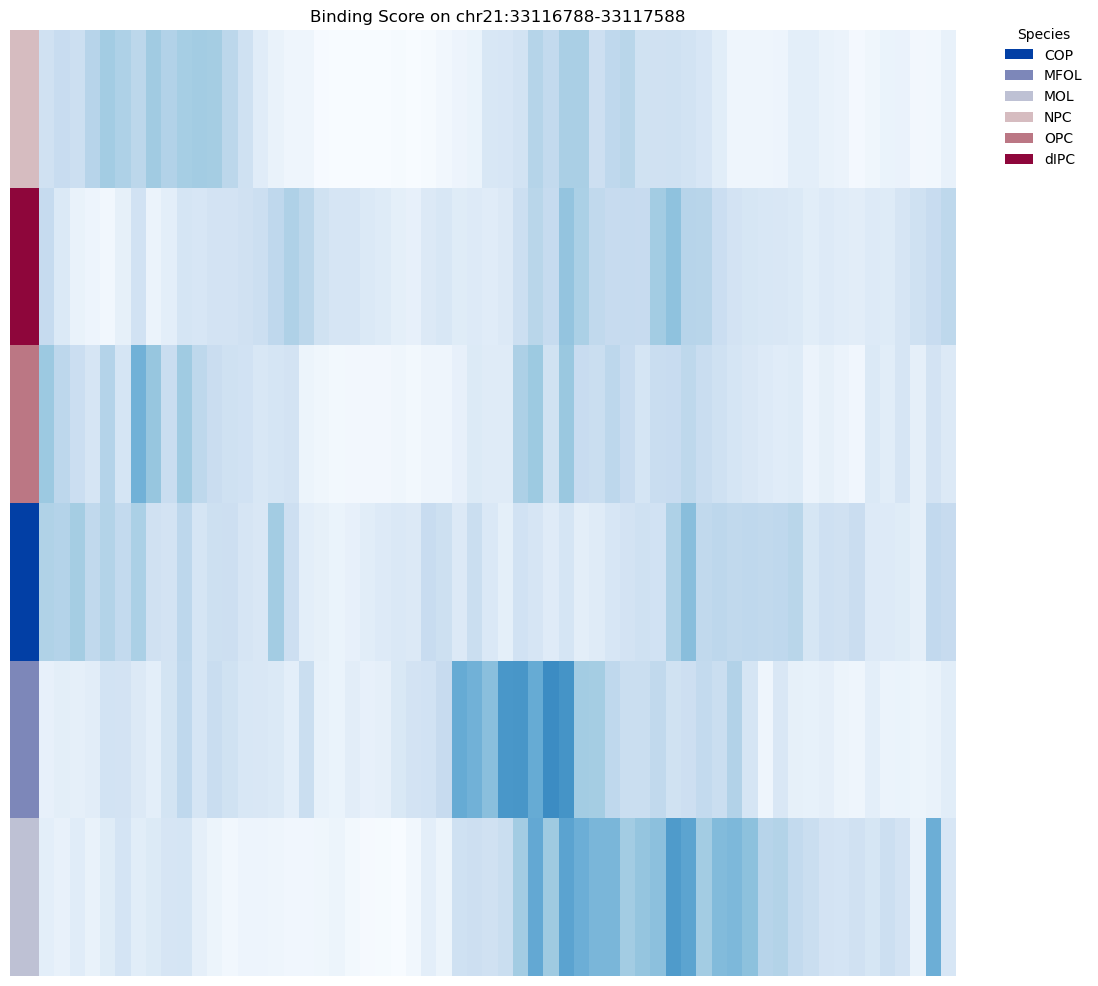

In [27]:
scp.pl.plot_binding_score(printer,
                       save_key='trial',
                       group_names=order,
                       kind='heatmap',
                       region=regions.iloc[2],
                       ax=None,
                       vmin=0.01, 
                       vmax=0.8,
                       row_label=order)

## Section III: Get Multi-scal footprinting score and visualization

warnings: This file can be really large when running it on thousands of groups and more than 10,000 regions!

In [28]:
# printer = scp.load_printer(f'{work_dir}/HSC_snATAC_gw12_scprinter.h5ad', scp.genome.hg38)
printer.load_disp_model()
start = time.time()
scp.tl.get_footprint_score(
    printer,
    grouping,
    uniq_groups,
    regions,
    modes=np.arange(2, 101),
    footprintRadius=None,
    flankRadius=None,
    n_jobs=8,
    save_key="trial_footprints",
    backed=True,
    overwrite=True)
print ("takes", time.time()-start)
print(printer)

estimated file size: 0.01 GB
Creating trial_footprints in printer.footprintsadata
obs=groups, var=regions
2666 100


Submitting jobs:   0%|          | 0/396 [00:00<?, ?it/s]

collecting multi-scale footprints:   0%|          | 0/396 [00:00<?, ?it/s]

takes 35.71836733818054
head project
AnnData object with n_obs x n_vars = 9282 x 0 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/HSC_snATAC_oligo_scprinter.h5ad'
    obs: 'sample', 'n_fragment', 'frac_dup', 'frac_mito', 'frag_path', 'frag_sample_name', 'tsse'
    uns: 'genome', 'group_bigwig', 'binding score', 'gff_db', 'reference_sequences', 'bias_bw', 'bias_path', 'insertion', 'peak_calling', 'footprints', 'unique_string'
    obsm: 'insertion_chr21', 'insertion_chr22', 'insertion_chr3', 'insertion_chr17', 'insertion_chr13', 'insertion_chr2', 'insertion_chrX', 'insertion_chr1', 'insertion_chr14', 'insertion_chr4', 'insertion_chr8', 'insertion_chr18', 'insertion_chr19', 'insertion_chr20', 'insertion_chrY', 'insertion_chr6', 'insertion_chr16', 'insertion_chr15', 'insertion_chr12', 'insertion_chr5', 'insertion_chr11', 'insertion_chr7', 'insertion_chr9', 'insertion_chr10'
detected 1 bindingscoreadata
name trial
AnnData object with n_ob

Now we have one bindingscoreadata (from above binding score prediction) and one footprintsadata from the footprinting experiment!

In [29]:
adata = printer.footprintsadata['trial_footprints']
a = adata.obsm['chr21:33115188-33115988']
print (a.shape)

(6, 99, 800)


shape of (#groups, #scales, #positions)

Visualize multiscale footprint! One per group

In [30]:
regions

,Chromosome,Start,End,identifier
chr21:33115188-33115988,chr21,33115188,33115988,chr21:33115188-33115988
chr21:33115988-33116788,chr21,33115988,33116788,chr21:33115988-33116788
chr21:33116788-33117588,chr21,33116788,33117588,chr21:33116788-33117588
chr21:33117588-33118388,chr21,33117588,33118388,chr21:33117588-33118388


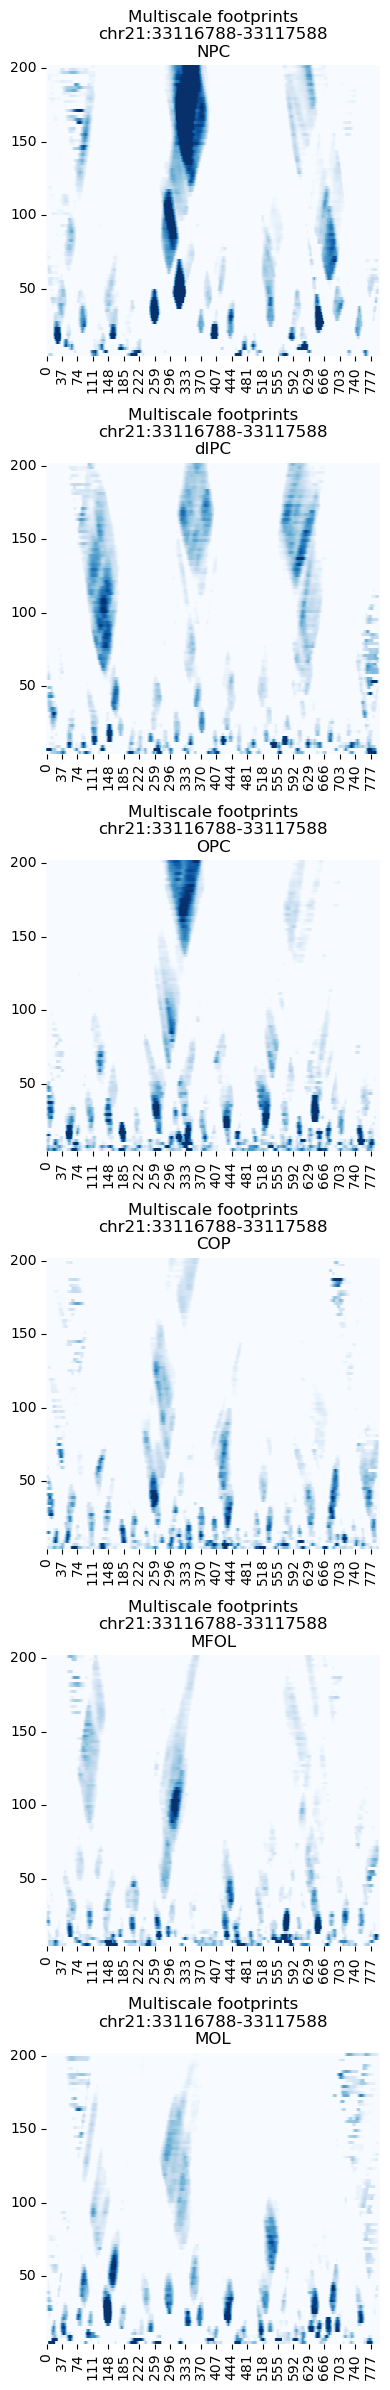

In [59]:
scp.pl.plot_footprints(printer,
                    save_key='trial_footprints',
                    group_names=uniq_groups[0:6],
                    region=regions.iloc[2],
                    scales=None,
                    ax=None,
                    cmap='Blues',
                    add_ticks=True,
                    edge_mode="nothing",
                    vmin=0.5,
                    vmax=2.0
                    )

In [36]:
import os
import matplotlib.pyplot as plt

for region in regions.index:
    # New figure and save
    plt.figure(figsize=(16, 8))  # New figure
    
    # Plot on current figure
    scp.pl.plot_footprints(
        printer,
        save_key='trial_footprints',
        group_names=uniq_groups[4:5],
        region=region,
        scales=None,
        ax=None, 
        cmap='Blues',
        add_ticks=True,
        edge_mode="nothing",
        vmin=0.5,
        vmax=2.0
    )
    
    # Save current figure
    plt.savefig(f"{work_dir}/plots/Oligo_footprints800_{uniq_groups[4:5][0]}_{region}.pdf", 
                bbox_inches='tight', 
                dpi=300,
                facecolor='white')
    plt.close()  # Close figure

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

You can also stack one scale across multiple groups!

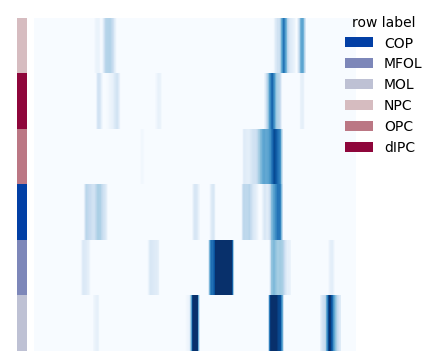

In [37]:
scp.pl.plot_footprints(printer,
                    save_key='trial_footprints',
                    group_names=order, # Again we sort the groups based on their cell type
                    row_label=order,
                    region=regions.iloc[1],
                    stack=True,
                    scales=[50],
                    ax=None,
                    cmap='Blues',
                    vmin=0.5,
                    vmax=2.0)

There's still some issue for aligning stuff. Basically, footprints are [100,900], binding score are [100, 900] but with 10bp resolution, insertion are [0, 1000]. As a temporal solution, one can manually adjust insertion range.

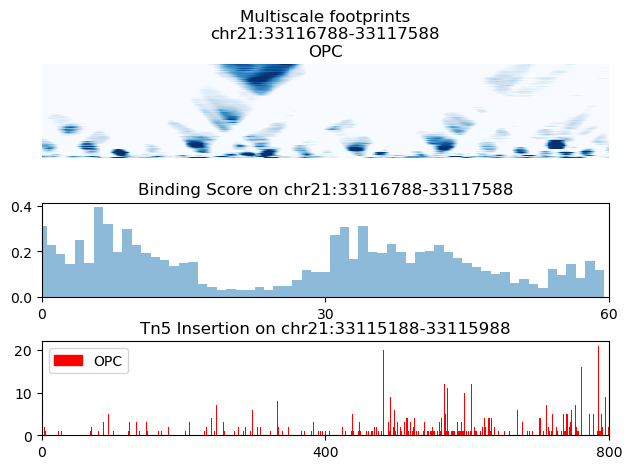

In [39]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 1)
scp.pl.plot_footprints(printer,
                    save_key='trial_footprints',
                    group_names=uniq_groups[4],
                    region=regions.iloc[2],
                    scales=None,
                    ax=axs[0],
                    cmap='Blues',
                    vmin=0.5,
                    vmax=2.0)
scp.pl.plot_binding_score(printer,
                       save_key='trial',
                       group_names=uniq_groups[4],
                       region=regions.iloc[2],
                       ax=axs[1],
                       alpha=0.5)
scp.pl.plot_group_atac(printer, 
                       grouping[4], 
                       uniq_groups[4],
                       "chr21:33115188-33115988",
                       ax=axs[2],
                       color="red")

In [17]:
printer.close()

## Section IV: Get realtime sync visualization of multi-scale footprints

first we need to use pp.sync_footprints to generate pseudo-bulk bigwig insertion profile to prepare for visualization

In [4]:
printer = scp.load_printer(f'{work_dir}/HSC_snATAC_oligo_scprinter.h5ad', scp.genome.hg38)
# Turn dataframe into groupings
# It requires printer because it will map barcode names to the index in the insertion sparse matrix

barcode_groups = pd.read_csv(f'{work_dir}/barcode_groups.csv', sep='\t')
barcodes = np.unique(barcode_groups.iloc[:, 0])
grouping, uniq_groups = scp.utils.df2cell_grouping(printer, barcode_groups)

loading oligo1_region /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/HSC_snATAC_oligo_scprinter_supp/oligo1_region.h5ad


In [8]:
scp.pp.export_bigwigs(printer,
                    grouping,
                    uniq_groups)

Loading insertion profiles
Creating bigwig for COP


  0%|          | 0/24 [00:00<?, ?it/s]

Creating bigwig for MFOL


  0%|          | 0/24 [00:00<?, ?it/s]

Creating bigwig for MOL


...

  0%|          | 0/24 [00:00<?, ?it/s]

Creating bigwig for OPC


  0%|          | 0/24 [00:00<?, ?it/s]

Creating bigwig for dIPC


  0%|          | 0/24 [00:00<?, ?it/s]

In [9]:
printer.load_disp_model()

In [ ]:
import plotly.io as pio
import plotly.graph_objs as go
pio.renderers.default = 'iframe'
import plotly.offline as py
import pandas as pd
import numpy as np
py.init_notebook_mode()

In [5]:
import pandas as pd
df = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/results/TFBS_scores_olig1.csv')
target_chrom = 'chr21'
target_start = 33115188
target_end = 33115988
filtered_df = df[
    (df['chrom'] == target_chrom) & 
    (df['start'] >= target_start) & 
    (df['end'] <= target_end)
]
tf_list = filtered_df['TF'].tolist()

In [6]:
motif = scp.motifs.JASPAR2022_core_Motifs(scp.genome.hg38, bg='genome')
motif.prep_scanner(
    tf_list,
    pseudocount=1e-4,
    pvalue=5e-5,
    window=7
)

<MOODS.scan.Scanner; proxy of <Swig Object of type 'MOODS::scan::Scanner *' at 0x14f6cbdb9d10> >

In [12]:
uniq_groups[0:6]

array(['COP', 'MFOL', 'MOL', 'NPC', 'OPC', 'dIPC'], dtype=object)

In [11]:
# Unlike staic plot dynamic plot the axis are always matched
scp.pl.sync_footprints(printer,
                    uniq_groups[0:6],
                    init_region='chr21:33115188-33115988',
                    motif_scanner=motif,
                    plotgenes=True)
# remote-ssh 1.0.20

FigureWidget({
    'data': [{'alignmentgroup': 'True',
              'base': [],
              'hovertemplate': 'TF=ZNF124<br>Start=%{base:,}<br>End=%{x:,}<extra></extra>',
              'legendgroup': 'ZNF124',
              'marker': {'color': '#9B9700', 'pattern': {'shape': ''}},
              'name': 'ZNF124',
              'offsetgroup': 'ZNF124',
              'orientation': 'h',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'uid': '7a775bf6-2d48-4f61-8482-1d8b37712324',
              'width': 1,
              'x': [],
              'xaxis': 'x',
              'y': [],
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'base': [],
              'hovertemplate': 'TF=ZNF33A<br>Start=%{base:,}<br>End=%{x:,}<extra></extra>',
              'legendgroup': 'ZNF33A',
              'marker': {'color': '#D790FF', 'pattern': {'shape': ''}},
              'name': 'ZNF33A',
              'off

In [12]:
printer.close()

In [82]:
printer

head project
Closed AnnData object
detected 1 bindingscoreadata
name trial
['Closed AnnData object']
detected 1 footprintsadata
name trial_footprints
['Closed AnnData object']
